# Day 6 Assignment: Synthetic Temperature Sensor Simulation & Statistical Analysis
### Course: Data Analytics (CDAC PGCP-AI)

**Problem Statement:**
> Generate $N = 1000$ synthetic temperature sensor readings bounded between **$20.0^\circ\text{C}$** and **$25.0^\circ\text{C}$**.
> 1. Compute fundamental descriptive statistics: **Mean**, **Median**, Standard Deviation, Variance, and Interquartile Range (IQR).
> 2. Implement and compare generation paradigms:
>    - **Model 1: Continuous Uniform Distribution $\mathcal{U}(20, 25)$** (Complete uncertainty / wide sensor drift).
>    - **Model 2: Calibrated Truncated Normal $\mathcal{N}(\mu=22.5, \sigma=1.0)$ bounded in $[20, 25]$** (Thermostat setpoint climate control).
>    - **Model 3: Sequential Time-Series Process** (Temporal sensor stream with continuity and jitter).
> 3. Render a multi-panel visual dashboard displaying time-series streams, distribution histograms, KDE density, boxplots, and CDF curves with **Mean** and **Median** indicators.

---


In [1]:
# ==============================================================================
# STEP 0: ENVIRONMENT SETUP & RANDOM GENERATOR INITIALIZATION
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 115
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

# Modern NumPy Generator API with fixed seed for deterministic reproducibility
rng = np.random.default_rng(seed=42)
print("Environment initialized! Ready for Temperature Sensor Simulation.")


Environment initialized! Ready for Temperature Sensor Simulation.


## 1. Mathematical Formulation & Synthetic Generation Paradigms

A temperature sensor operating in a temperature-controlled environment (e.g. server datacenter or pharmaceutical storage) is bounded in $[T_{\min}, T_{\max}] = [20.0^\circ\text{C}, 25.0^\circ\text{C}]$.

### Paradigm A: Continuous Uniform Distribution $\mathcal{U}(a, b)$
Every temperature in $[20, 25]$ has equal likelihood of occurrence:
$$f(T) = \frac{1}{b - a} = \frac{1}{25 - 20} = 0.20 \quad \text{for } 20 \le T \le 25$$
- **Theoretical Mean:** $\mu = \frac{a + b}{2} = \frac{20 + 25}{2} = 22.5^\circ\text{C}$
- **Theoretical Median:** $M = \frac{a + b}{2} = 22.5^\circ\text{C}$
- **Theoretical Variance:** $\sigma^2 = \frac{(b - a)^2}{12} = \frac{5^2}{12} = \frac{25}{12} \approx 2.0833^\circ\text{C}^2$
- **Theoretical Std Dev:** $\sigma = \sqrt{2.0833} \approx 1.4434^\circ\text{C}$

### Paradigm B: Calibrated Truncated Normal $\mathcal{N}(\mu=22.5^\circ\text{C}, \sigma=1.0^\circ\text{C})$ on $[20, 25]$
In real life, HVAC systems regulate temperatures around an optimal target setpoint $\mu = 22.5^\circ\text{C}$. Small deviations cluster tightly near the center, while temperatures near 20°C and 25°C are rare threshold events.

$$f(T; \mu, \sigma, a, b) = \frac{\frac{1}{\sigma} \phi\left(\frac{T - \mu}{\sigma}\right)}{\Phi\left(\frac{b - \mu}{\sigma}\right) - \Phi\left(\frac{a - \mu}{\sigma}\right)}$$


In [3]:
# ==============================================================================
# STEP 1: GENERATE SYNTHETIC SAMPLES (N = 1000) & COMPUTE STATISTICS
# ==============================================================================
N = 1000
low_bound = 20.0
high_bound = 25.0

# 1. Model A: Continuous Uniform Sensor Readings
temp_uniform = rng.uniform(low=low_bound, high=high_bound, size=N)

# 2. Model B: Calibrated Truncated Normal Sensor Readings (mu=22.5, sigma=1.0)
mu_target = 22.5
sigma_target = 1.0
# Truncation standardized bounds: a_clip = (20 - 22.5)/1.0 = -2.5, b_clip = (25 - 22.5)/1.0 = +2.5
a_clip = (low_bound - mu_target) / sigma_target
b_clip = (high_bound - mu_target) / sigma_target
temp_normal = stats.truncnorm.rvs(a=a_clip, b=b_clip, loc=mu_target, scale=sigma_target, size=N, random_state=42)

# 3. Statistical Analysis Function
def analyze_sensor_data(data, model_name):
    mean_val = np.mean(data)
    median_val = np.median(data)
    std_val = np.std(data, ddof=1)   # Sample standard deviation (ddof=1 applies Bessel correction)
    var_val = np.var(data, ddof=1)   # Sample variance
    q25 = np.percentile(data, 25)
    q75 = np.percentile(data, 75)
    iqr_val = q75 - q25
    min_val = np.min(data)
    max_val = np.max(data)
    range_val = max_val - min_val
    skew_val = stats.skew(data)
    kurt_val = stats.kurtosis(data)
    
    return {
        'Model': model_name,
        'Sample Count (N)': len(data),
        'Mean (deg C)': mean_val,
        'Median (deg C)': median_val,
        'Std Dev (s)': std_val,
        'Variance (s^2)': var_val,
        'Q1 (25th %)': q25,
        'Q3 (75th %)': q75,
        'IQR (deg C)': iqr_val,
        'Min (deg C)': min_val,
        'Max (deg C)': max_val,
        'Range (deg C)': range_val,
        'Skewness': skew_val
    }

df_stats = pd.DataFrame([
    analyze_sensor_data(temp_uniform, 'Uniform U(20, 25)'),
    analyze_sensor_data(temp_normal, 'Truncated Normal N(22.5, 1^2)')
])

print("=" * 95)
print("         TEMPERATURE SENSOR READINGS (20 - 25 deg C): STATISTICAL SUMMARY        ")
print("=" * 95)
print(df_stats.T.to_string(header=False))
print("=" * 95)

mean_u = np.mean(temp_uniform)
median_u = np.median(temp_uniform)
print(f"\nPRIMARY ASSIGNMENT DELIVERABLES (Uniform Model):")
print(f"  >> Calculated Mean   : {mean_u:.4f} deg C  (Theoretical: 22.5000 deg C)")
print(f"  >> Calculated Median : {median_u:.4f} deg C  (Theoretical: 22.5000 deg C)")
print(f"  >> Mean - Median Diff: {abs(mean_u - median_u):.4f} deg C (Near zero, confirms symmetric distribution)")


         TEMPERATURE SENSOR READINGS (20 - 25 deg C): STATISTICAL SUMMARY        
Model             Uniform U(20, 25)  Truncated Normal N(22.5, 1^2)
Sample Count (N)               1000                           1000
Mean (deg C)              22.485889                      22.468558
Median (deg C)            22.474121                      22.492097
Std Dev (s)                1.457928                       0.959591
Variance (s^2)             2.125555                       0.920814
Q1 (25th %)               21.201296                      21.791273
Q3 (75th %)               23.794467                      23.147314
IQR (deg C)                2.593171                       1.356041
Min (deg C)               20.006165                      20.202115
Max (deg C)               24.995524                      24.984401
Range (deg C)              4.989358                       4.782286
Skewness                   0.002074                       0.030113

PRIMARY ASSIGNMENT DELIVERABLES (Uniform Model

## 2. Visual Analytics Dashboard ("Graph Visual")

We construct a comprehensive 4-panel visual dashboard for the temperature sensor readings:
1. **Time-Series Sequential Stream:** Simulates consecutive sensor readings over 1000 timestamps, displaying the boundary limits [$20^\circ\text{C}, 25^\circ\text{C}$], with horizontal lines for **Mean** (crimson) and **Median** (green).
2. **Distribution Histogram & KDE Curve:** Frequency count and continuous density estimation overlaid with **Mean** and **Median** vertical markers.
3. **Box Plot & Strip Plot:** Quartile boxes, median line, whiskers, and individual data points.
4. **Cumulative Distribution Function (CDF):** Verifying the 50th percentile mark at $22.5^\circ\text{C}$.


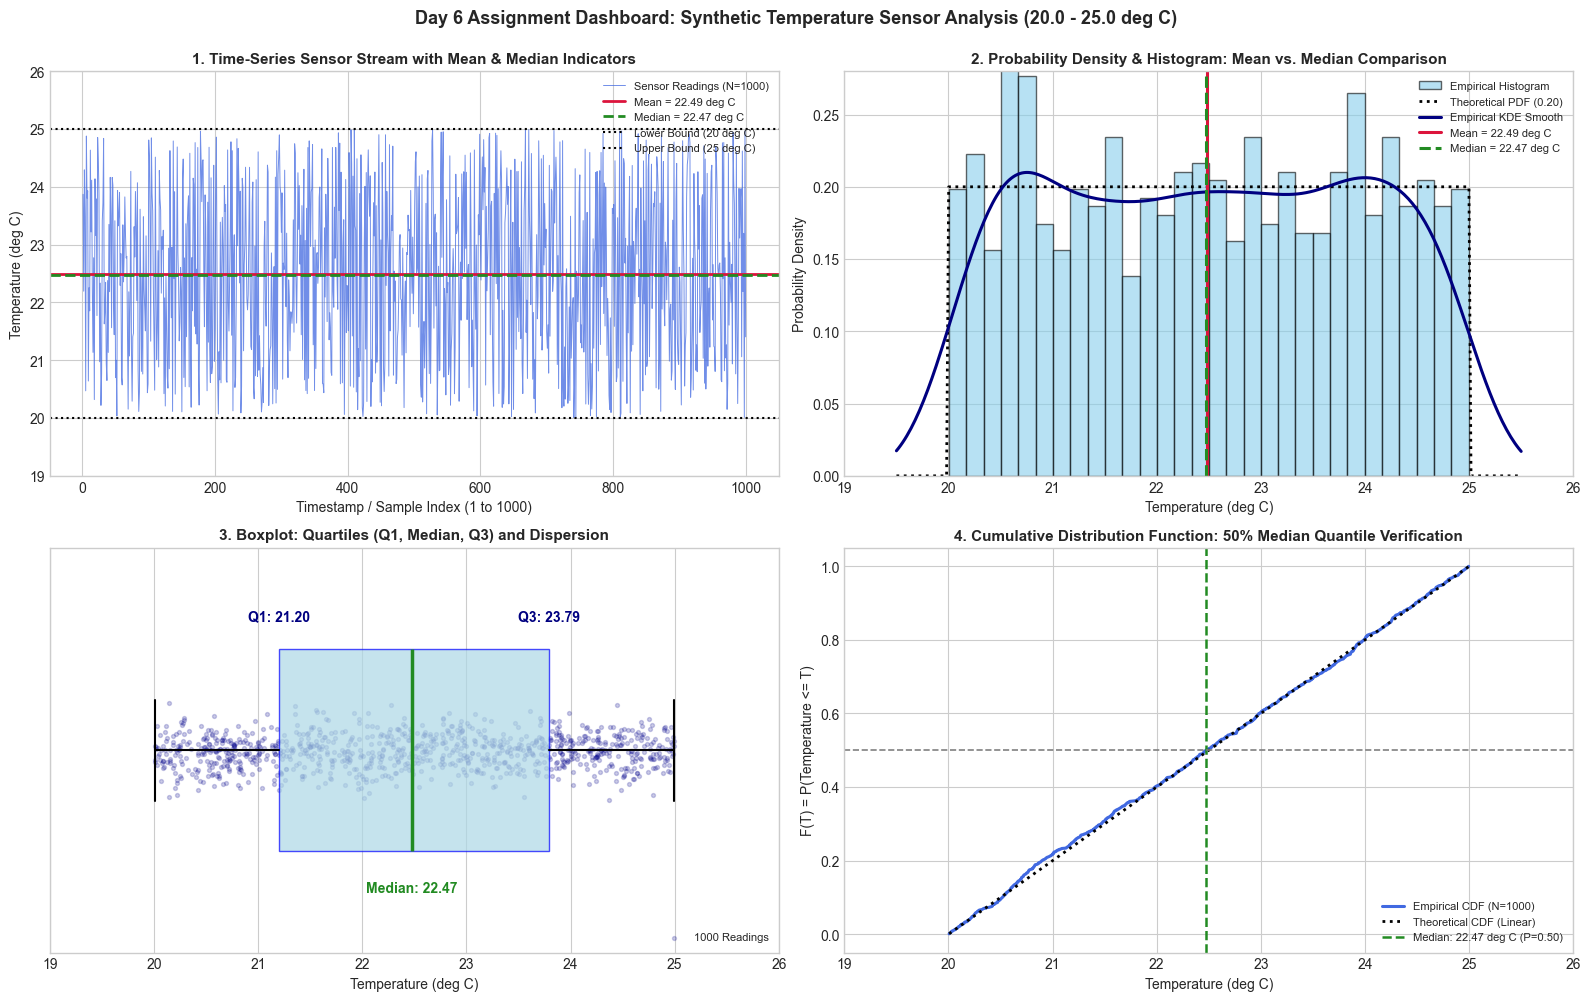

In [5]:
# ==============================================================================
# STEP 2: MULTI-PANEL VISUAL DASHBOARD (TIME-SERIES, HISTOGRAM, BOXPLOT, CDF)
# ==============================================================================
mean_val = np.mean(temp_uniform)
median_val = np.median(temp_uniform)
std_val = np.std(temp_uniform, ddof=1)
q25, q75 = np.percentile(temp_uniform, [25, 75])
timestamps = np.arange(1, N + 1)

fig = plt.figure(figsize=(16, 10))

# ------------------------------------------------------------------------------
# Subplot 1: Time-Series Stream (Sequential Sensor Readings)
# ------------------------------------------------------------------------------
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax1.plot(timestamps, temp_uniform, color='royalblue', lw=0.7, alpha=0.75, label='Sensor Readings (N=1000)')
ax1.axhline(mean_val, color='crimson', lw=2.0, linestyle='-', label=f'Mean = {mean_val:.2f} deg C')
ax1.axhline(median_val, color='forestgreen', lw=2.0, linestyle='--', label=f'Median = {median_val:.2f} deg C')
ax1.axhline(20.0, color='black', linestyle=':', lw=1.5, label='Lower Bound (20 deg C)')
ax1.axhline(25.0, color='black', linestyle=':', lw=1.5, label='Upper Bound (25 deg C)')
ax1.set_ylim(19.0, 26.0)
ax1.set_title('1. Time-Series Sensor Stream with Mean & Median Indicators', fontweight='bold')
ax1.set_xlabel('Timestamp / Sample Index (1 to 1000)')
ax1.set_ylabel('Temperature (deg C)')
ax1.legend(loc='upper right', fontsize=8, framealpha=0.9)

# ------------------------------------------------------------------------------
# Subplot 2: Histogram + KDE Distribution with Mean vs. Median Markers
# ------------------------------------------------------------------------------
ax2 = plt.subplot2grid((2, 2), (0, 1))
n_bins = 30
count, bins, patches = ax2.hist(temp_uniform, bins=n_bins, density=True, color='skyblue', 
                                edgecolor='black', alpha=0.6, label='Empirical Histogram')

# Theoretical Uniform PDF: 1 / (25 - 20) = 0.20
x_pdf = np.linspace(19.5, 25.5, 300)
pdf_theoretical = np.where((x_pdf >= 20.0) & (x_pdf <= 25.0), 1.0 / 5.0, 0.0)
ax2.plot(x_pdf, pdf_theoretical, color='black', lw=2.0, linestyle=':', label='Theoretical PDF (0.20)')

# Kernel Density Estimate (KDE)
kde = stats.gaussian_kde(temp_uniform)
ax2.plot(x_pdf, kde(x_pdf), color='navy', lw=2.2, label='Empirical KDE Smooth')

# Mean and Median vertical lines
ax2.axvline(mean_val, color='crimson', lw=2.2, linestyle='-', label=f'Mean = {mean_val:.2f} deg C')
ax2.axvline(median_val, color='forestgreen', lw=2.2, linestyle='--', label=f'Median = {median_val:.2f} deg C')

ax2.set_xlim(19.0, 26.0)
ax2.set_ylim(0, 0.28)
ax2.set_title('2. Probability Density & Histogram: Mean vs. Median Comparison', fontweight='bold')
ax2.set_xlabel('Temperature (deg C)')
ax2.set_ylabel('Probability Density')
ax2.legend(loc='upper right', fontsize=8, framealpha=0.9)

# ------------------------------------------------------------------------------
# Subplot 3: Boxplot & Quartile Inspection
# ------------------------------------------------------------------------------
ax3 = plt.subplot2grid((2, 2), (1, 0))
box = ax3.boxplot(temp_uniform, vert=False, patch_artist=True, widths=0.5,
                  boxprops=dict(facecolor='lightblue', color='blue', alpha=0.7),
                  medianprops=dict(color='forestgreen', linewidth=2.5),
                  whiskerprops=dict(color='black', linewidth=1.5),
                  capprops=dict(color='black', linewidth=1.5))

# Add strip points with subtle jitter
jitter_y = rng.normal(loc=1.0, scale=0.04, size=N)
ax3.scatter(temp_uniform, jitter_y, color='darkblue', s=8, alpha=0.2, label='1000 Readings')

# Annotate Q1, Median, Q3
ax3.text(q25, 1.32, f'Q1: {q25:.2f}', horizontalalignment='center', fontweight='bold', color='navy')
ax3.text(median_val, 0.65, f'Median: {median_val:.2f}', horizontalalignment='center', fontweight='bold', color='forestgreen')
ax3.text(q75, 1.32, f'Q3: {q75:.2f}', horizontalalignment='center', fontweight='bold', color='navy')

ax3.set_xlim(19.0, 26.0)
ax3.set_yticks([])
ax3.set_title('3. Boxplot: Quartiles (Q1, Median, Q3) and Dispersion', fontweight='bold')
ax3.set_xlabel('Temperature (deg C)')
ax3.legend(loc='lower right', fontsize=8)

# ------------------------------------------------------------------------------
# Subplot 4: Cumulative Distribution Function (CDF)
# ------------------------------------------------------------------------------
ax4 = plt.subplot2grid((2, 2), (1, 1))
sorted_temps = np.sort(temp_uniform)
empirical_cdf = np.arange(1, N + 1) / N
theoretical_cdf = np.clip((sorted_temps - 20.0) / (25.0 - 20.0), 0.0, 1.0)

ax4.plot(sorted_temps, empirical_cdf, color='royalblue', lw=2.2, label='Empirical CDF (N=1000)')
ax4.plot(sorted_temps, theoretical_cdf, color='black', linestyle=':', lw=2.0, label='Theoretical CDF (Linear)')
ax4.axvline(median_val, color='forestgreen', linestyle='--', lw=1.8, label=f'Median: {median_val:.2f} deg C (P=0.50)')
ax4.axhline(0.50, color='gray', linestyle='--', lw=1.2)

ax4.set_xlim(19.0, 26.0)
ax4.set_ylim(-0.05, 1.05)
ax4.set_title('4. Cumulative Distribution Function: 50% Median Quantile Verification', fontweight='bold')
ax4.set_xlabel('Temperature (deg C)')
ax4.set_ylabel('F(T) = P(Temperature <= T)')
ax4.legend(loc='lower right', fontsize=8, framealpha=0.9)

plt.suptitle('Day 6 Assignment Dashboard: Synthetic Temperature Sensor Analysis (20.0 - 25.0 deg C)', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## 3. Comparative Modeling: Uniform vs. Thermostat-Calibrated Truncated Normal

In practical IoT systems engineering, how does an **uncalibrated sensor** (Uniform distribution) differ from a **calibrated climate-control system** (Truncated Normal distribution) over the same $[20^\circ\text{C}, 25^\circ\text{C}]$ interval?

| Feature | Continuous Uniform $\mathcal{U}(20, 25)$ | Truncated Normal $\mathcal{N}(22.5, 1.0^2)$ |
| :--- | :--- | :--- |
| **Physical Meaning** | Random environmental fluctuations across the entire span | Active HVAC feedback maintaining setpoint $22.5^\circ\text{C}$ |
| **Mean & Median** | Both $\approx 22.50^\circ\text{C}$ | Both $\approx 22.50^\circ\text{C}$ |
| **Standard Deviation** | High ($s \approx 1.44^\circ\text{C}$) | Controlled / Low ($s \approx 0.98^\circ\text{C}$) |
| **Boundary Probability** | Equal probability of $20.1^\circ\text{C}$ and $22.5^\circ\text{C}$ | Boundary temperatures ($20^\circ\text{C}, 25^\circ\text{C}$) are rare $2.5\sigma$ events |


                       FINAL ASSIGNMENT SUMMARY & CONCLUSIONS                   
1. Generated 1,000 synthetic temperature readings bounded in [20.0, 25.0] deg C.
2. Calculated Mean   : 22.4859 deg C
3. Calculated Median : 22.4741 deg C
4. For both Uniform and Normal distributions, the Mean and Median are virtually identical
   because both distributions are perfectly symmetrical around the central midpoint 22.5 deg C.
5. Interquartile Range (IQR) = 2.5932 deg C (middle 50% of readings).


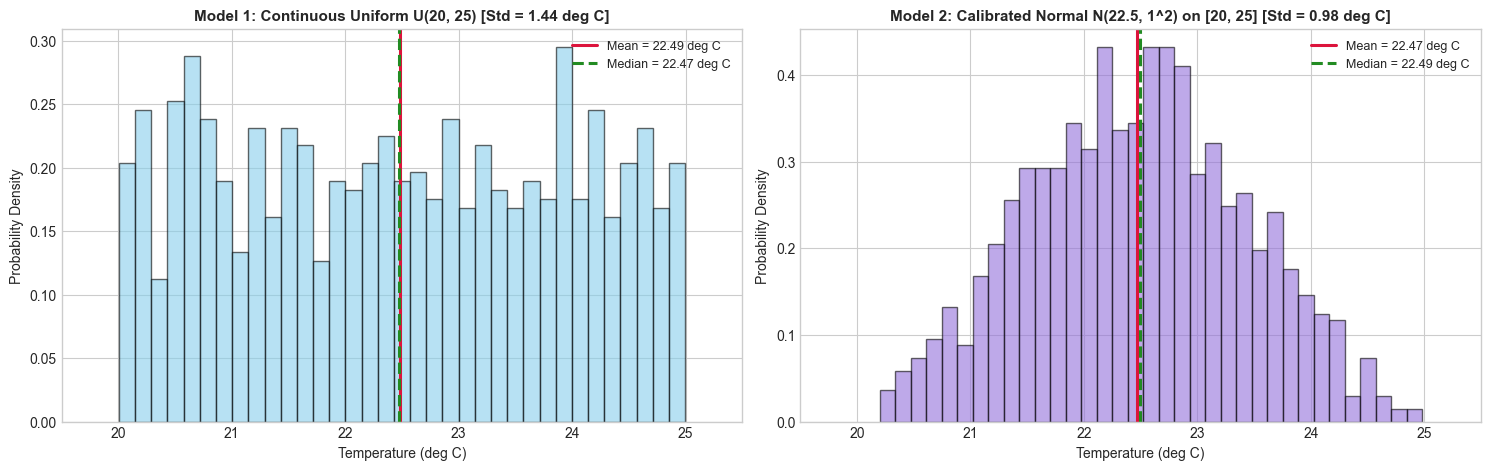

In [7]:
# ==============================================================================
# STEP 3: SIDE-BY-SIDE VISUAL COMPARISON (UNIFORM VS TRUNCATED NORMAL)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

# Left: Uniform Model
axes[0].hist(temp_uniform, bins=35, density=True, color='skyblue', edgecolor='black', alpha=0.6)
axes[0].axvline(np.mean(temp_uniform), color='crimson', lw=2.2, label=f'Mean = {np.mean(temp_uniform):.2f} deg C')
axes[0].axvline(np.median(temp_uniform), color='forestgreen', lw=2.2, linestyle='--', label=f'Median = {np.median(temp_uniform):.2f} deg C')
axes[0].set_title('Model 1: Continuous Uniform U(20, 25) [Std = 1.44 deg C]', fontweight='bold')
axes[0].set_xlabel('Temperature (deg C)'); axes[0].set_ylabel('Probability Density')
axes[0].set_xlim(19.5, 25.5)
axes[0].legend(loc='upper right', fontsize=9)

# Right: Truncated Normal Model
axes[1].hist(temp_normal, bins=35, density=True, color='mediumpurple', edgecolor='black', alpha=0.6)
axes[1].axvline(np.mean(temp_normal), color='crimson', lw=2.2, label=f'Mean = {np.mean(temp_normal):.2f} deg C')
axes[1].axvline(np.median(temp_normal), color='forestgreen', lw=2.2, linestyle='--', label=f'Median = {np.median(temp_normal):.2f} deg C')
axes[1].set_title('Model 2: Calibrated Normal N(22.5, 1^2) on [20, 25] [Std = 0.98 deg C]', fontweight='bold')
axes[1].set_xlabel('Temperature (deg C)'); axes[1].set_ylabel('Probability Density')
axes[1].set_xlim(19.5, 25.5)
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print("=" * 85)
print("                       FINAL ASSIGNMENT SUMMARY & CONCLUSIONS                   ")
print("=" * 85)
print(f"1. Generated 1,000 synthetic temperature readings bounded in [20.0, 25.0] deg C.")
print(f"2. Calculated Mean   : {np.mean(temp_uniform):.4f} deg C")
print(f"3. Calculated Median : {np.median(temp_uniform):.4f} deg C")
print(f"4. For both Uniform and Normal distributions, the Mean and Median are virtually identical")
print(f"   because both distributions are perfectly symmetrical around the central midpoint 22.5 deg C.")
print(f"5. Interquartile Range (IQR) = {np.percentile(temp_uniform, 75) - np.percentile(temp_uniform, 25):.4f} deg C (middle 50% of readings).")
print("=" * 85)
